<!-- VIDEO: 1 / RAG 개요 — LLM에 외부 지식이 필요한 이유 -->

# 06. RAG 데이터 준비 + 파이프라인

> **학습 목표**
> 1. **RAG가 해결하는 두 가지 문제** — 할루시네이션과 비공개 지식의 활용.
> 2. 다양한 문서 로더(Markdown, PDF, CSV) 사용법을 익힌다.
> 3. **텍스트 분할**의 동작 원리(`chunk_size`, `overlap`)를 시각적으로 이해한다.
> 4. **임베딩(embedding)** 의 개념과 의미 기반 검색의 원리를 학습한다.
> 5. **FAISS** 벡터 스토어의 저장, 로드, 유사도 검색 절차를 수행한다.
> 6. LCEL로 RAG 체인을 간결하게 구성한다.
> 7. 한국 정부 정책 및 사내 HR 정책 문서를 활용한 한국어 RAG 사례를 실습한다.
>
> **선수 지식**: 02번(LCEL), 04번(Tools — 후속 Agentic RAG의 기반).

---

## RAG가 필요한 이유

LLM은 다음 두 가지 한계를 가집니다.

| 한계 | 예시 | RAG의 해결 방식 |
|------|------|----------------|
| 학습 시점 이후 정보를 알지 못함 | "이번 분기 우리 회사 매출은?" | 최신 데이터베이스나 문서를 검색해 컨텍스트로 함께 전달 |
| 비공개(private) 지식에 접근 불가 | "우리 회사 휴가 정책은?" | 사내 문서를 임베딩 후, 질의와 관련도가 높은 부분만 검색해 컨텍스트로 전달 |

### RAG 파이프라인 개요

```mermaid
flowchart LR
    subgraph PREP ["📂 문서 준비 단계 — 1회 수행"]
        DOC(["PDF / MD / CSV"]):::input
        SPLIT["청크 분할"]:::node
        EMB1["임베딩 모델"]:::node
        VEC["1024차원 벡터"]:::node
        FAISS[("FAISS 저장")]:::store
        DOC --> SPLIT --> EMB1 --> VEC --> FAISS
    end

    subgraph QUERY ["💬 질문 처리 단계 — 매 호출마다 수행"]
        Q(["사용자 질문"]):::input
        EMB2["임베딩"]:::node
        SEARCH["FAISS top-k 검색"]:::node
        CHUNKS["관련 청크 3~5개"]:::node
        LLM["LLM<br/>컨텍스트 + 질문 전달"]:::node
        ANS(["답변 생성"]):::output
        Q --> EMB2 --> SEARCH --> CHUNKS --> LLM --> ANS
    end

    FAISS -.->|"유사도 검색"| SEARCH

    classDef input  fill:#4f46e5,stroke:#3730a3,color:#fff
    classDef node   fill:#1e293b,stroke:#475569,color:#e2e8f0
    classDef store  fill:#0f172a,stroke:#f59e0b,color:#fcd34d
    classDef output fill:#059669,stroke:#047857,color:#fff
```

본 노트북에서는 `data/hr_manual.md`와 `data/it_guide.md`를 활용해 **사내 매뉴얼 QA 시스템**의 검색 파이프라인을 구축합니다. 후속 자료(`advanced/07`)에서는 이 검색 파이프라인을 **에이전트의 도구로 래핑한 Agentic RAG**로 확장합니다.

---

## 1. 환경 설정

이전 노트북과 동일한 LLM 초기화 패턴을 사용합니다. 추가로 임베딩 모델로는 Ollama 로컬 모델 **`bge-m3`**(BAAI 다국어 임베딩, 1024차원)를 사용합니다. API 키 없이 동작하며 한국어 품질이 우수합니다.

> **사전 준비**: 본 노트북을 실행하기 전 `ollama pull bge-m3` 로 임베딩 모델을 받아 두세요(약 1.2GB). 자세한 안내는 [SETUP.md](./SETUP.md) 3번 섹션을 참고하세요.

In [1]:
from dotenv import load_dotenv
load_dotenv()

from langchain.chat_models import init_chat_model
from langchain_ollama import OllamaEmbeddings
from pathlib import Path
import os

# LLM은 노트북 02~05와 동일하게 키 보유 옵션 중 하나를 선택합니다.
# 임베딩은 Ollama bge-m3(1024차원)로 통일 — API 키 불필요, 한국어 우수.

# ✅ Option 1: Google Gemini 2.5 Flash-Lite (무료) — thinking_budget=0 으로 추론 토큰 비활성화
# llm = init_chat_model("google_genai:gemini-2.5-flash-lite", temperature=0,
#                        model_kwargs={"thinking_budget": 0})

# ✅ Option 2: Groq Qwen3 32B (무료) — reasoning_effort="none" 으로 <think> 토큰 비활성화
# llm = init_chat_model("groq:qwen/qwen3-32b", temperature=0, reasoning_effort="none")

# ✅ Option 3: Ollama Gemma 4 E4B (로컬) — reasoning=False 으로 <think> 토큰 비활성화
llm = init_chat_model("ollama:gemma4:e4b", temperature=0, reasoning=False)

# ⚙️ Option 4: OpenAI (유료) — reasoning 토큰 없음, 추가 파라미터 불필요
# llm = init_chat_model("openai:gpt-4.1-mini", temperature=0)


# 임베딩 — 사전 준비: `ollama pull bge-m3`
embeddings = OllamaEmbeddings(model="bge-m3")  # 1024차원

DATA_DIR = Path("./data")
INDEX_DIR = Path("./faiss_index")
print("✓ ready (LLM + Ollama bge-m3 임베딩)")

✓ ready (LLM + Ollama bge-m3 임베딩)


## 2. 문서 로더 (Document Loaders)

LangChain은 다양한 파일 형식을 통일된 `Document` 객체로 변환하는 로더를 제공합니다. `Document`는 `page_content`(본문 텍스트)와 `metadata`(딕셔너리)로 구성되며, 이후 분할 및 임베딩 단계에서 일관된 인터페이스로 사용됩니다.

### 2.1 Markdown / Text 로더

`TextLoader`는 일반 텍스트 및 Markdown 파일을 단일 `Document`로 로드합니다. 인코딩 옵션(`encoding="utf-8"`)을 명시하는 것을 권장합니다.

In [2]:
from langchain_community.document_loaders import TextLoader

hr_docs = TextLoader(str(DATA_DIR / "hr_manual.md"), encoding="utf-8").load()
it_docs = TextLoader(str(DATA_DIR / "it_guide.md"), encoding="utf-8").load()

print(f"HR 매뉴얼: {len(hr_docs)}개 document, {len(hr_docs[0].page_content)}자")
print(f"IT 가이드: {len(it_docs)}개 document, {len(it_docs[0].page_content)}자")
print("\n앞 200자 미리보기:")
print(hr_docs[0].page_content[:200])

HR 매뉴얼: 1개 document, 2024자
IT 가이드: 1개 document, 2809자

앞 200자 미리보기:
# ABC 주식회사 — HR 매뉴얼

본 문서는 ABC 주식회사 임직원의 인사·복리후생 관련 주요 규정을 정리한 것입니다.
실제 정책은 사내 HR 포털을 우선 참조해주시기 바랍니다.

---

## 1. 연차 휴가

### 1.1 연차 신청 기한
- 연차 휴가는 **사용 희망일 최소 3 영업일 전**에 HR 포털에서 신청해야 합니다.
- 긴급한 사정(병가·


### 2.2 PDF 로더

PDF 파일은 `PyPDFLoader`로 로드합니다. 각 페이지가 별도의 `Document` 객체로 변환되며, 페이지 번호는 `metadata`에 자동 기록됩니다.

In [3]:
from langchain_community.document_loaders import PyPDFLoader

# 본 강의는 한국어 마크다운 매뉴얼 위주로 진행하며, PDF는 옵션입니다.
# 직접 PDF를 추가해 보고 싶다면 data/ 폴더에 transformer.pdf 같은 파일을 넣고 아래 셀을 실행하세요.
pdf_path = DATA_DIR / "transformer.pdf"
if pdf_path.exists():
    pdf_docs = PyPDFLoader(str(pdf_path)).load()
    print(f"페이지 수: {len(pdf_docs)}")
    print("\n첫 페이지 메타데이터:", pdf_docs[0].metadata)
    print("\n첫 페이지 본문 (앞 300자):")
    print(pdf_docs[0].page_content[:300])
else:
    print("ℹ PDF 파일이 없어 PDF 로더 데모는 건너뜁니다.")
    print("  → 직접 시도하려면 data/ 폴더에 임의 PDF 파일을 추가한 뒤 다시 실행하세요.")
    print("  → 한국어 PDF 예시: 정부24 공공정책 PDF, 주택임대차보호법 등")

ℹ PDF 파일이 없어 PDF 로더 데모는 건너뜁니다.
  → 직접 시도하려면 data/ 폴더에 임의 PDF 파일을 추가한 뒤 다시 실행하세요.
  → 한국어 PDF 예시: 정부24 공공정책 PDF, 주택임대차보호법 등


### 2.3 CSV 로더

`CSVLoader`는 CSV 파일의 각 행을 별도의 `Document`로 로드합니다. 행 단위의 짧은 레코드(FAQ, 상품 목록 등)를 RAG 데이터로 활용할 때 적합합니다.

In [4]:
from langchain_community.document_loaders import CSVLoader

csv_path = DATA_DIR / "kbo_teams_2023.csv"
if csv_path.exists():
    csv_docs = CSVLoader(str(csv_path), encoding="utf-8").load()
    print(f"{len(csv_docs)}개 row → 각 row = 1 Document")
    print("\n첫 row:")
    print(csv_docs[0].page_content)
else:
    print("csv 없음 — 건너뜀")

csv 없음 — 건너뜀


<!-- VIDEO: 2 / 청크 분할과 임베딩 -->

## 3. 텍스트 분할 (Text Splitter)

LLM의 컨텍스트 윈도우는 제한적이며, 임베딩 모델 또한 짧은 텍스트일수록 검색 정밀도가 높습니다. 따라서 원본 문서를 **의미 단위의 청크**로 분할하는 전처리가 필요합니다.

### `chunk_size`와 `overlap`의 동작


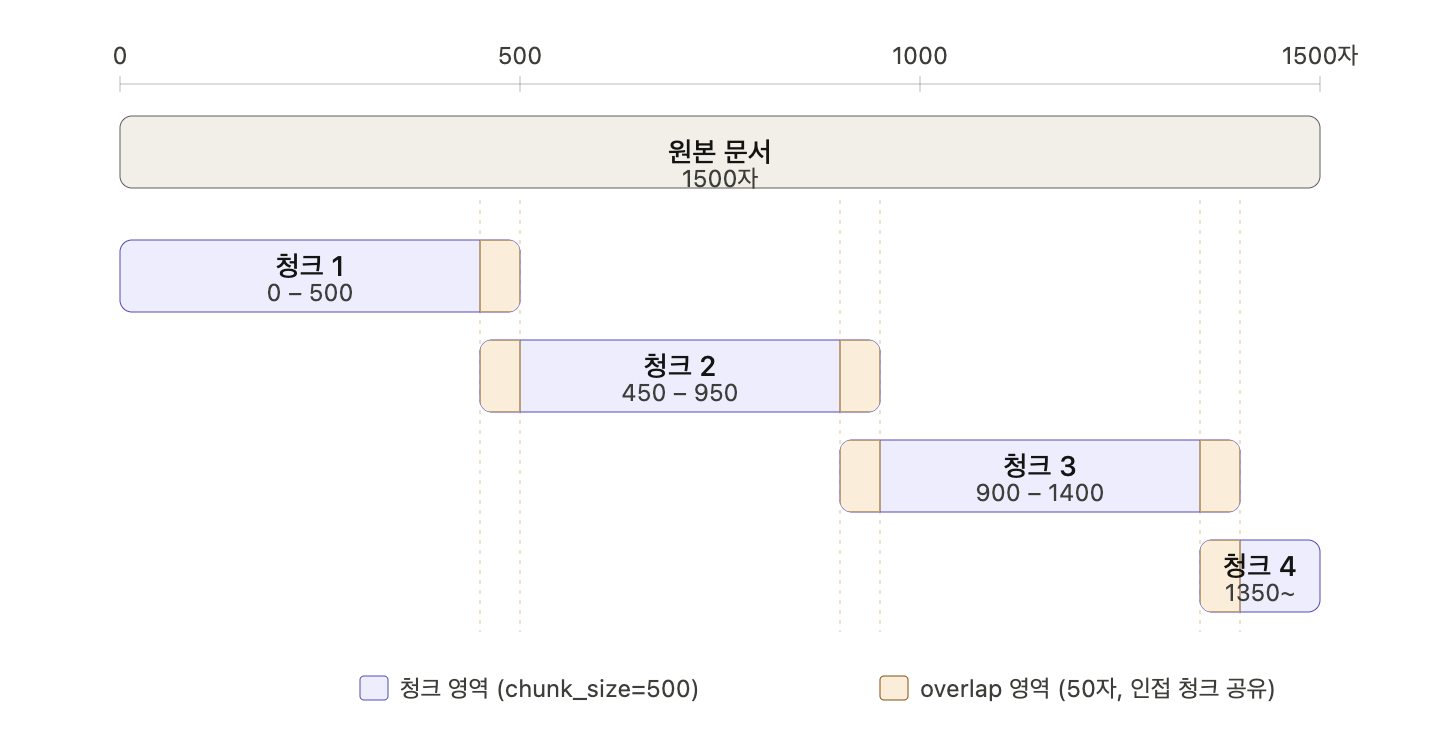

- `chunk_size`: 한 청크의 최대 길이입니다. 일반적으로 영어 기준 500~1500자, 한국어 기준 200~800자가 권장됩니다.
- `chunk_overlap`: 인접 청크가 공유하는 길이입니다. 일반적으로 `chunk_size`의 10~20%를 권장합니다.
- **Overlap의 역할**: "회의록 작성은 영업일 3일 이내에…"와 같은 문장이 청크 경계에서 잘려 검색 시 누락되는 것을 방지합니다.

### 3.1 RecursiveCharacterTextSplitter (표준)

가장 일반적으로 사용되는 분할기입니다. 우선순위가 부여된 구분자 리스트(`\n\n` → `\n` → `. ` → ` `)를 순차적으로 시도하며 `chunk_size` 제약을 충족시킵니다.

In [5]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50,
    separators=["\n\n", "\n", ". ", " ", ""],
)

all_raw = hr_docs + it_docs
chunks = splitter.split_documents(all_raw)

print(f"원본 문서: {len(all_raw)}개")
print(f"분할 후 청크: {len(chunks)}개")
print(f"\n첫 청크 (len={len(chunks[0].page_content)}):")
print(chunks[0].page_content[:300])
print("\n메타데이터:", chunks[0].metadata)

원본 문서: 2개
분할 후 청크: 12개

첫 청크 (len=441):
# ABC 주식회사 — HR 매뉴얼

본 문서는 ABC 주식회사 임직원의 인사·복리후생 관련 주요 규정을 정리한 것입니다.
실제 정책은 사내 HR 포털을 우선 참조해주시기 바랍니다.

---

## 1. 연차 휴가

### 1.1 연차 신청 기한
- 연차 휴가는 **사용 희망일 최소 3 영업일 전**에 HR 포털에서 신청해야 합니다.
- 긴급한 사정(병가·경조사)의 경우 사후 신청이 가능하며, 부서장 승인을 받습니다.

### 1.2 연차 부여 일수
- 입사 1년 미만: 매월 만근 시 1일씩 발생 (최대 11일)
- 입사 1년 이상

메타데이터: {'source': 'data/hr_manual.md'}


### 3.2 SemanticChunker — 의미 기반 분할 (선택)

문장 간 임베딩 거리를 기준으로 분할 위치를 결정합니다. 토큰 단위가 아닌 **의미 경계**를 기준으로 자르므로 검색 품질이 향상되는 경향이 있으나, 임베딩 API 호출 비용이 추가로 발생합니다.

```python
from langchain_experimental.text_splitter import SemanticChunker
sem = SemanticChunker(embeddings, breakpoint_threshold_type="percentile")
sem_chunks = sem.split_documents(all_raw)
```

본 강의에서는 비용을 고려해 `RecursiveCharacterTextSplitter`만 실습합니다.

## 4. 임베딩 모델

### 임베딩(Embedding)의 정의

텍스트를 **다차원 공간상의 벡터**로 변환하는 기법입니다. 의미가 유사한 문장의 벡터는 서로 가깝고, 의미가 다른 문장의 벡터는 서로 멀리 위치합니다.

```
"연차 신청 기한"        ●
                         ↘ (가까움)
"휴가는 며칠 전?"         ●

       ↕ (멈)

"노트북 반납 절차"        ●
                         ↘ (가까움)
"PC 회수 방법"            ●
```

`bge-m3` 모델은 **1024차원** 벡터를 생성합니다. 참고로 Google `text-embedding-004`는 768차원, OpenAI `text-embedding-3-small`은 1536차원, `text-embedding-3-large`는 3072차원입니다.

### RAG에서의 임베딩 역할

키워드 매칭이 아닌 **의미 기반 매칭**으로 질의와 가장 관련도 높은 문서를 검색하기 위해 사용됩니다. 동일한 의미를 다른 단어로 표현한 경우(예: "연차 기한" ↔ "휴가는 며칠 전")에도 검색 가능하다는 것이 핵심 이점입니다.

In [6]:
import numpy as np

# 1. 쿼리와 문서 임베딩
query_text = "연차 신청은 며칠 전까지 해야 하나요?"
doc_text_1 = "연차 휴가는 최소 3일 전에 신청해야 합니다."
doc_text_2 = "노트북 반납은 퇴사일 기준으로 진행됩니다."

query_vec = np.array(embeddings.embed_query(query_text))
doc_vec_1 = np.array(embeddings.embed_query(doc_text_1))
doc_vec_2 = np.array(embeddings.embed_query(doc_text_2))

print(f"벡터 차원: {len(query_vec)}")
print(f"최초 5개 값: {query_vec[:5]}\n")

# 2. 코사인 유사도 계산
# bge-m3 의 raw 출력은 단위 벡터로 정규화되어 있지 않을 수 있으므로,
# 명시적으로 |a||b| 로 나누어 코사인 유사도를 구합니다.
def cosine(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

sim_1 = cosine(query_vec, doc_vec_1)
sim_2 = cosine(query_vec, doc_vec_2)

print(f"[질문] {query_text}")
print(f"  → [유사도: {sim_1:.4f}] 문서1: {doc_text_1}")
print(f"  → [유사도: {sim_2:.4f}] 문서2: {doc_text_2}")

벡터 차원: 1024
최초 5개 값: [-0.04750207  0.02728853 -0.01493732 -0.02661712 -0.02006926]

[질문] 연차 신청은 며칠 전까지 해야 하나요?
  → [유사도: 0.7941] 문서1: 연차 휴가는 최소 3일 전에 신청해야 합니다.
  → [유사도: 0.4293] 문서2: 노트북 반납은 퇴사일 기준으로 진행됩니다.


<!-- VIDEO: 3 / FAISS 벡터 스토어 저장과 검색 -->

## 5. FAISS 벡터 스토어

**FAISS(Facebook AI Similarity Search)** 는 빠르고 가벼운 벡터 인덱스 라이브러리로, 로컬 파일 시스템에 저장 가능합니다. 수백만 규모의 벡터를 밀리초 단위로 검색할 수 있어 프로토타이핑 및 중소 규모 운영 환경에 적합합니다.

### 5.1 인덱스 생성 및 저장

청크 리스트와 임베딩 모델을 입력하여 FAISS 인덱스를 생성하고, `save_local()`로 디스크에 영속화합니다.

In [7]:
from langchain_community.vectorstores import FAISS

# 청크들을 임베딩하고 FAISS 인덱스에 저장
vectorstore = FAISS.from_documents(documents=chunks, embedding=embeddings)

# 로컬에 저장
INDEX_DIR.mkdir(exist_ok=True)
vectorstore.save_local(str(INDEX_DIR), index_name="company_manual")
print(f"✓ FAISS 인덱스 저장 완료: {INDEX_DIR}/company_manual.*")

✓ FAISS 인덱스 저장 완료: faiss_index/company_manual.*


### 5.2 저장된 인덱스 로드

이미 생성된 인덱스가 있을 경우 `load_local()`로 재사용할 수 있습니다. 임베딩 단계는 비용과 시간이 소요되므로 인덱스를 영속화하고 재사용하는 것이 권장됩니다.

In [8]:
vectorstore = FAISS.load_local(
    str(INDEX_DIR),
    embeddings,
    index_name="company_manual",
    allow_dangerous_deserialization=True,   # pickle 신뢰 플래그
)
print("✓ 인덱스 로드 완료")

✓ 인덱스 로드 완료


### 5.3 유사도 검색

`similarity_search(query, k=3)`은 질의와 가장 가까운 k개의 청크를 반환합니다. 반환된 `Document` 객체에는 본문(`page_content`)과 메타데이터(`metadata`)가 포함됩니다.

In [9]:
query = "연차는 며칠 전까지 신청해야 하나요?"
results = vectorstore.similarity_search(query, k=3)

for i, doc in enumerate(results, 1):
    print(f"[{i}] {doc.page_content[:200]}")
    print(f"    source: {doc.metadata.get('source')}")
    print()

[1] # ABC 주식회사 — HR 매뉴얼

본 문서는 ABC 주식회사 임직원의 인사·복리후생 관련 주요 규정을 정리한 것입니다.
실제 정책은 사내 HR 포털을 우선 참조해주시기 바랍니다.

---

## 1. 연차 휴가

### 1.1 연차 신청 기한
- 연차 휴가는 **사용 희망일 최소 3 영업일 전**에 HR 포털에서 신청해야 합니다.
- 긴급한 사정(병가·
    source: data/hr_manual.md

[2] - 출장 종료 후 **5 영업일 이내** 영수증과 함께 정산 신청

---

## 4. 재택근무

- 팀별 **주 2일** 재택근무 가능
- 사전에 팀장 승인 필요 (HR 포털 신청)
- 재택근무 중에도 09:00~18:00 업무시간 준수
- 회사 노트북 외 개인 기기로 사내 시스템 접속 금지

---

## 5. 급여

### 5.1 지급일
- 매월 **
    source: data/hr_manual.md

[3] ### 6.2 건강검진
- 매년 1회 종합 건강검진 무료 제공 (지정 병원)
- 만 30세 이상 여직원: 자궁경부암 검사 추가
- 만 40세 이상: 위·대장 내시경 격년 제공

### 6.3 자기계발 지원
- 도서구입비: 분기당 10만원 (영수증 제출)
- 외부 교육: 연 100만원 한도 (사전 신청·이수 보고)
- 어학시험 응시료: 연 2회까지 지원

#
    source: data/hr_manual.md



### 5.4 점수 포함 검색

`similarity_search_with_score()`는 각 결과에 대한 거리 점수를 함께 반환합니다. 임계값 기반 필터링(예: 일정 점수 미만은 제외) 등 후처리에 활용할 수 있습니다.

In [10]:
# 낮은 점수 = 가까움 (distance)
scored = vectorstore.similarity_search_with_score(query, k=3)
for doc, score in scored:
    print(f"[score={score:.4f}] {doc.page_content[:120]}...")

[score=0.6633] # ABC 주식회사 — HR 매뉴얼

본 문서는 ABC 주식회사 임직원의 인사·복리후생 관련 주요 규정을 정리한 것입니다.
실제 정책은 사내 HR 포털을 우선 참조해주시기 바랍니다.

---

## 1. 연차 휴가
...
[score=0.8703] - 출장 종료 후 **5 영업일 이내** 영수증과 함께 정산 신청

---

## 4. 재택근무

- 팀별 **주 2일** 재택근무 가능
- 사전에 팀장 승인 필요 (HR 포털 신청)
- 재택근무 중에도 09:00~...
[score=0.9821] ### 6.2 건강검진
- 매년 1회 종합 건강검진 무료 제공 (지정 병원)
- 만 30세 이상 여직원: 자궁경부암 검사 추가
- 만 40세 이상: 위·대장 내시경 격년 제공

### 6.3 자기계발 지원
- 도서구...


### 5.5 Retriever로 변환

LCEL 체인에 연결할 수 있도록, 벡터 스토어를 `as_retriever()`로 `Runnable` 인터페이스로 변환합니다. `search_kwargs={"k": 3}` 등으로 검색 파라미터를 지정할 수 있습니다.

In [11]:
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 4},
)

retrieved = retriever.invoke("VPN 접속이 안 될 때 어떻게 하나요?")
print(f"{len(retrieved)}개 문서 반환")
print(retrieved[0].page_content[:200])

4개 문서 반환
---

## 3. 자주 발생하는 문제 및 해결

### 3.1 VPN 접속 불가
| 증상 | 해결 방법 |
|------|----------|
| 인증 실패 | 비밀번호 만료 확인 → SSO 포털에서 갱신 |
| 연결 시도 중 멈춤 | 다른 네트워크(예: 모바일 핫스팟) 시도 |
| OTP 거부 | 휴대폰 시간 동기화 확인 (자동 시간으로 설정) |
| 


<!-- VIDEO: 4 / LCEL 기반 RAG 체인 -->

## 6. RAG 체인 — LCEL 기반 구성

`retriever | prompt | llm | parser` 형태의 체인으로 RAG 워크플로를 구성합니다. 후속 노트북(07)에서는 이 검색 단계를 에이전트의 도구로 래핑한 Agentic RAG 패턴을 다룹니다.

In [12]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

rag_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "당신은 사내 업무 어시스턴트입니다. "
     "주어진 컨텍스트만 근거로 답하세요. "
     "컨텍스트에 없는 내용은 '문서에서 찾을 수 없습니다' 라고 답하세요.\n\n"
     "[컨텍스트]\n{context}"),
    ("human", "{question}"),
])

def format_docs(docs):
    return "\n\n---\n\n".join(d.page_content for d in docs)

rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | rag_prompt
    | llm
    | StrOutputParser()
)

print(rag_chain.invoke("연차는 며칠 전까지 신청해야 하나요?"))

연차 휴가는 **사용 희망일 최소 3 영업일 전**에 HR 포털에서 신청해야 합니다.

다만, 긴급한 사정(병가·경조사)의 경우에는 사후 신청이 가능하며, 부서장 승인을 받아야 합니다.


In [13]:
print(rag_chain.invoke("VPN 접속 문제를 해결하는 방법을 알려주세요."))

VPN 접속 문제의 증상에 따라 해결 방법이 다릅니다.

**증상별 해결 방법:**

*   **인증 실패:** 비밀번호 만료를 확인하고 SSO 포털에서 갱신해야 합니다.
*   **연결 시도 중 멈춤:** 다른 네트워크(예: 모바일 핫스팟)를 시도해 보세요.
*   **OTP 거부:** 휴대폰 시간 동기화가 되어 있는지 확인하고, 자동 시간으로 설정해야 합니다.
*   **모든 방법 실패:** IT 헬프데스크 (내선 1700 / ithelp@abc-example.com)로 연락해야 합니다.

**참고 사항:**

*   **OTP (이중 인증)**는 모든 SSO 로그인에 필수이며, 분실 시 IT 헬프데스크에 사원증과 본인 확인을 거쳐 재등록해야 합니다.
*   **VPN 사용 권장 사항:** 재택근무 중 사내 시스템 접속 시 VPN 사용이 필수이며, 카페나 공항 등 공용 Wi-Fi 사용 시에는 VPN 사용이 강력히 권장됩니다. 사용 후에는 반드시 종료해야 합니다.


In [14]:
# 문서에 없는 정보 — 정직한 '모름' 응답이 나와야 함
print(rag_chain.invoke("2030년에 CEO 가 누가 될 예정인가요?"))

문서에서 찾을 수 없습니다.


## 7. 다른 벡터 스토어와의 비교

| 벡터 스토어 | 장점 | 단점 | 적합한 용도 |
|---|---|---|---|
| **FAISS** | 빠르고 가벼움, 로컬 저장 가능 | 클라우드, 분산 기능 약함 | 로컬 또는 중소 규모, 프로토타입 |
| **Chroma** | 메타데이터 필터링 강력, 자동 영속화 | 단일 노드 운영 | 중소 규모, 빠른 시작 |
| **Pinecone** | 완전 관리형 SaaS, 확장성 우수 | 유료, 네트워크 의존성 | 프로덕션, 대규모 운영 |
| **Milvus / Weaviate** | 오픈소스, 분산 지원 | 운영 복잡도 높음 | 자체 운영 대규모 환경 |

본 강의에서는 단순함을 위해 FAISS만 실습하지만, 다른 벡터 스토어도 `import` 경로만 변경하면 LangChain의 `VectorStore` 인터페이스를 동일하게 사용할 수 있습니다.

```python
# Chroma 예시 (참고)
# from langchain_chroma import Chroma
# chroma = Chroma.from_documents(chunks, embedding=embeddings, persist_directory="./chroma_db")

# Pinecone 예시 (참고)
# from langchain_pinecone import PineconeVectorStore
# pc = PineconeVectorStore.from_documents(chunks, embedding=embeddings, index_name="kea")
```

---

## 실습 과제: 사내 FAQ RAG 구축

**요구사항**

1. `data/` 디렉터리에 짧은 텍스트 파일(예: `my_faq.txt`)을 작성하고 3~5개의 Q&A를 입력합니다.
2. 로더 → 분할 → 임베딩 → FAISS 저장으로 이어지는 전체 파이프라인을 실행합니다.
3. `rag_chain`으로 FAQ 관련 질문에 응답하도록 구성합니다.
4. FAQ에 포함되지 않은 질문에 대해 "찾을 수 없습니다"와 같이 정직하게 응답하는지 확인합니다.

In [ ]:
# 여기에 코드를 작성하세요
# Hint:
# from pathlib import Path
# Path("./data/my_faq.txt").write_text("Q: ...\nA: ...\n\nQ: ...\nA: ...")
# TextLoader → RecursiveCharacterTextSplitter → FAISS.from_documents(...)


<details>
<summary>모범 답안 보기</summary>

```python
faq_text = """
Q: 점심시간은 언제인가요?
A: 점심시간은 12:00~13:00 입니다.

Q: 재택근무 신청 방법은?
A: HR 포털에서 팀장 승인 후 신청합니다.

Q: 경조사 휴가 일수는?
A: 본인 결혼 5일, 부모 사망 5일입니다.
"""

from pathlib import Path
Path("./data/my_faq.txt").write_text(faq_text, encoding="utf-8")

faq_docs = TextLoader("./data/my_faq.txt", encoding="utf-8").load()
faq_chunks = splitter.split_documents(faq_docs)
faq_vs = FAISS.from_documents(faq_chunks, embedding=embeddings)
faq_retriever = faq_vs.as_retriever(search_kwargs={"k": 2})

faq_chain = (
    {"context": faq_retriever | format_docs, "question": RunnablePassthrough()}
    | rag_prompt
    | llm
    | StrOutputParser()
)

print(faq_chain.invoke("점심시간 언제야?"))
print(faq_chain.invoke("연봉 협상은 언제 하나요?"))  # 문서에 정보 없음
```

</details>

---

## 트러블슈팅

| 증상 | 원인 | 해결 방법 |
|---|---|---|
| `FileNotFoundError: ./data/hr_manual.md` | 작업 디렉터리 불일치 | 프로젝트 루트에서 노트북 실행, 또는 `DATA_DIR = Path(...)` 절대 경로 사용 |
| 임베딩 차원 불일치 오류 (재로드 시) | 인덱스 생성 시와 로드 시 임베딩 모델이 다름 | 동일 모델(`bge-m3`, 1024차원)을 유지하거나 인덱스를 재생성 |
| `allow_dangerous_deserialization` 경고 | FAISS가 pickle을 사용해 직렬화 | 본인이 생성한 인덱스만 로드. 외부 출처 인덱스는 신뢰하지 않음 |
| 검색 결과가 의도와 다름 | `chunk_size`가 과도하게 큼 | 한국어는 300~600자 범위 권장. `chunk_overlap` 증가도 검토 |
| 임베딩 호출 실패 (`Connection refused`) | Ollama 서비스 미실행 | Ollama 앱 실행 후 `ollama list` 로 `bge-m3` 보유 확인. 미보유 시 `ollama pull bge-m3` |
| 대량 인덱싱 시 응답 지연 | Ollama가 단일 프로세스에서 임베딩 처리 | `FAISS.from_documents` 호출 시 `chunks` 를 적절한 단위로 끊어 점진적으로 추가하거나, GPU 가속을 활용 |
| 한국어 PDF 글자 깨짐 | `PyPDFLoader`가 일부 PDF에서 텍스트 추출 실패 | `pdfplumber` 또는 `unstructured`로 교체 시도 |

---

## 마무리

본 노트북에서 학습한 내용은 다음과 같습니다.

- RAG가 해결하는 두 가지 한계 (할루시네이션, 비공개 지식)
- 다양한 문서 로더 (Markdown, PDF, CSV) 활용
- 청크 분할의 원리 (`chunk_size`, `chunk_overlap`)
- 임베딩의 개념과 의미 기반 매칭의 동작
- FAISS 벡터 스토어의 저장, 로드, 검색, Retriever 변환
- LCEL 기반 RAG 체인 구성 (`retriever | prompt | llm | parser`)
- 컨텍스트에 정보가 없을 때 정직하게 "모름"으로 응답하도록 유도하는 패턴

### 입문 트랙 정리

| 노트북 | 핵심 주제 |
|--------|----------|
| 01 | LLM 동작 원리, OpenAI SDK 기본 호출, JSON 출력 |
| 02 | LangChain v1.0 LCEL, `init_chat_model`, Runnable 4종 |
| 03 | Few-shot 프롬프팅, Pydantic 구조화 출력, Example Selector |
| 04 | `@tool`, `bind_tools`, 수동 ReAct 루프, Tavily 검색 |
| 05 | `create_agent`, `MemorySaver`, 동적 프롬프트 미들웨어 |
| 06 | RAG 파이프라인 — 임베딩, FAISS, LCEL 체인 |

입문 트랙을 완료하셨습니다.